# Rigorous Pipeline Experimentation Suite

Notebook structure:
- Cell 1-5: setup and reusable helpers
- Cell 6-9: instrumented pipeline functions and sweep definitions
- Cell 10-12: orchestrator/CVAE sweeps and pipeline reference run
- Cell 13-14: target length challenge (2..12), figures, cleanup

This notebook is pipeline-only: no non-agentic baseline comparison is executed.

In [2]:
import sys
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator

DATA_PATH = REPO_ROOT / 'database' / 'training_data.json'
EXPERIMENT_DIR = REPO_ROOT / 'experiments' / 'pipeline_experimentations'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

RUN_PROFILE = 'fast'  # 'fast' or 'full'
RUN_ORCHESTRATOR_SWEEP = True
RUN_CVAE_SWEEP = True
RUN_LENGTH_SWEEP = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Repo root: {REPO_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Run profile: {RUN_PROFILE}')

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path exists: True
CUDA available: True
Run profile: fast


In [3]:
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2

TARGET = {
    'dbaasp_id': 'DBAASPS_373',
    'sequence': 'KLFKRWKHLFR',
    'length': 11,
    'ph': 7.0,
    'molecular_weight': 1558.9480000000003,
    'logp': -0.992100000000006,
    'net_charge': 5.0,
    'isoelectric_point': 12.18,
    'hydrophobicity': 1.05,
    'cathionicity': 6,
}

AA = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21
MAX_LEN = 14

def build_biologist(reference_peptide: str, score_temperature: float = 50.0):
    return ESMBiologistGlobalL2(
        reference_peptide=reference_peptide,
        batch_size=16,
        score_temperature=score_temperature,
    )

In [4]:
# --- Data Loading ---
VOCAB_SIZE = 21  # 20 AA + PAD
PAD_IDX = 20
MAX_LEN = 14
AA_TO_IDX = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}

def encode_one_hot_with_pad(sequences: List[str], max_len: int = MAX_LEN) -> torch.Tensor:
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x

def build_condition_tensor(dataframe: pd.DataFrame, condition_dim: int = 32) -> torch.Tensor:
    cond = torch.zeros(len(dataframe), condition_dim, dtype=torch.float32)
    # Map dataframe columns to condition tensor explicitly
    cond[:, 0] = torch.tensor(dataframe['length'].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe['molecular_weight'].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe['net_charge'].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe['isoelectric_point'].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe['hydrophobicity'].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe['cathionicity'].values, dtype=torch.float32)
    cond[:, 6] = 0.5 # Default hydrophobic moment
    cond[:, 7] = torch.tensor(dataframe['logp'].values, dtype=torch.float32)
    # Remaining dimensions filled with defaults or ignored by CVAE depending on implementation
    return cond

loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        'sequence', 'length', 'ph', 'molecular_weight', 'logp',
        'net_charge', 'isoelectric_point', 'hydrophobicity', 'cathionicity'
    ],
    fillna_defaults={
        'length': 10,
        'ph': 7.0,
        'molecular_weight': 1500.0,
        'logp': 0.0,
        'net_charge': 0.0,
        'isoelectric_point': 7.0,
        'hydrophobicity': 0.0,
        'cathionicity': 0.0,
    },
    normalize_sequence=True,
    sequence_column='sequence',
    keep_standard_amino_acids_only=True,
)

df = loader.get_data().copy()
sequences = df['sequence'].tolist()
lengths_t = torch.tensor(df['length'].astype(int).values, dtype=torch.long)
x_t = encode_one_hot_with_pad(sequences, max_len=MAX_LEN)
conditions_t = build_condition_tensor(df, condition_dim=32)

print(f'Dataset rows: {len(df)}')
print(f'x shape: {tuple(x_t.shape)}')
print(f'conditions shape: {tuple(conditions_t.shape)}')
display(df.head(3))

Dataset rows: 4410
x shape: (4410, 294)
conditions shape: (4410, 32)


,sequence,length,ph,molecular_weight,logp,net_charge,isoelectric_point,hydrophobicity,cathionicity
0,KVVVKWVVKVVK,12,7.0,1648.291,5.6026,5.0,14.0,-1.07,4
1,LFIFFF,6,7.0,832.059,3.2860,1.0,14.0,-3.25,0
2,KAAAKWAAKAAK,12,7.0,1451.913,1.1499,5.0,14.0,0.33,4


In [5]:
# --- Model Helpers ---

def build_chemist_from_target(
    target: Dict[str, Any],
    width_scale: float = 1.0,
    length_min: float = 2.0,
    length_max: float = 20.0,
    length_weight: float = 1.0,
) -> ChemistAgent:
    ph = float(target['ph'])
    target_length = float(target['length'])
    min_len = max(length_min, target_length if width_scale <= 1.0 else target_length - 1.0)
    max_len = min(length_max, target_length if width_scale <= 1.0 else target_length + 1.0)

    target_mw = float(target['molecular_weight'])
    mw_span = max(250.0, 0.35 * target_mw)
    mw_min = max(200.0, target_mw - mw_span)
    mw_max = target_mw + mw_span

    target_charge = float(target['net_charge'])
    charge_span = max(1.5, 0.5 * abs(target_charge) * width_scale)
    charge_min = target_charge - charge_span
    charge_max = target_charge + charge_span

    target_ip = float(target['isoelectric_point'])
    ip_span = 2.5 * width_scale
    ip_min = max(3.0, target_ip - ip_span)
    ip_max = min(14.0, target_ip + ip_span)

    target_hydro = float(target['hydrophobicity'])
    hydro_span = 1.5 * width_scale
    hydro_min = target_hydro - hydro_span
    hydro_max = target_hydro + hydro_span

    target_logp = float(target['logp'])
    logp_span = 2.0 * width_scale
    logp_min = target_logp - logp_span
    logp_max = target_logp + logp_span

    return ChemistAgent(
        config=ChemistConfig(
            ph=ph,
            length=RangeTarget(min=min_len, max=max_len, target=target_length, weight=length_weight),
            molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=target_mw, weight=1.0),
            logp=RangeTarget(min=logp_min, max=logp_max, target=target_logp, weight=1.0),
            net_charge=RangeTarget(min=charge_min, max=charge_max, target=target_charge, weight=1.0),
            isoelectric_point=RangeTarget(min=ip_min, max=ip_max, target=target_ip, weight=1.0),
            hydrophobicity=RangeTarget(min=hydro_min, max=hydro_max, target=target_hydro, weight=1.0),
        )
    )

def model_cache_path(
    latent_dim: int,
    hidden_dim: int,
    epochs: int,
    lr: float,
    kl_anneal_epochs: int = 0,
    batch_size: int = 64,
) -> Path:
    lr_text = str(lr).replace('.', 'p')
    return EXPERIMENT_DIR / (
        f'cvae_lat{latent_dim}_hid{hidden_dim}_ep{epochs}_lr{lr_text}'
        f'_kl{kl_anneal_epochs}_bs{batch_size}.pth'
    )

def get_or_train_cvae(
    latent_dim: int,
    hidden_dim: int,
    epochs: int,
    lr: float,
    kl_anneal_epochs: int,
    batch_size: int = 64,
) -> CVAEGenerator:
    model = CVAEGenerator(max_len=MAX_LEN, latent_dim=latent_dim, hidden_dim=hidden_dim, condition_dim=32)
    path = model_cache_path(
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        epochs=epochs,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
        batch_size=batch_size,
    )

    if path.exists():
        model.load_model(str(path))
        print(f"Loaded cached model: {path.name}")
        return model

    print(f"Training CVAE model: {path.name}")
    model.train_model(
        data=x_t,
        conditions=conditions_t,
        lengths=lengths_t,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
    )
    model.save_model(str(path))
    print(f"Saved model: {path.name}")
    return model

In [6]:
# --- Experiment Helpers ---

def safe_float(x: Any, default: float = 0.0) -> float:
    try:
        return float(x)
    except Exception:
        return default

def sequence_distance(a: str, b: str) -> float:
    n = max(len(a), len(b), 1)
    a_pad = a.ljust(n, '-')
    b_pad = b.ljust(n, '-')
    return sum(c1 != c2 for c1, c2 in zip(a_pad, b_pad)) / n

def mean_pairwise_distance(peptides: List[str]) -> float:
    if len(peptides) < 2:
        return 0.0
    dists = []
    for i in range(len(peptides)):
        for j in range(i + 1, len(peptides)):
            dists.append(sequence_distance(peptides[i], peptides[j]))
    return float(np.mean(dists)) if dists else 0.0

def bigram_entropy(peptides: List[str]) -> float:
    from collections import Counter
    counts = Counter()
    total = 0
    for p in peptides:
        for i in range(max(0, len(p) - 1)):
            counts[p[i:i+2]] += 1
            total += 1
    if total == 0:
        return 0.0
    probs = np.array([v / total for v in counts.values()], dtype=float)
    return float(-(probs * np.log2(probs + 1e-12)).sum())

def summarize_topk(top_rows: List[Dict[str, Any]], top_k: int = 10) -> Dict[str, float]:
    if not top_rows:
        return {
            'top1_score': 0.0,
            'topk_mean_score': 0.0,
            'validity_rate': 0.0,
            'unique_ratio': 0.0,
            'mean_pairwise_distance': 0.0,
            'bigram_entropy': 0.0,
        }

    top = top_rows[:top_k]
    scores = [safe_float(r.get('combined_score', r.get('score', 0.0))) for r in top]
    peptides = [r.get('peptide', '') for r in top if r.get('peptide')]
    valid = [bool(r.get('in_limits', False)) for r in top]

    return {
        'top1_score': float(max(scores)) if scores else 0.0,
        'topk_mean_score': float(np.mean(scores)) if scores else 0.0,
        'validity_rate': float(np.mean(valid)) if valid else 0.0,
        'unique_ratio': float(len(set(peptides)) / max(len(peptides), 1)),
        'mean_pairwise_distance': mean_pairwise_distance(peptides),
        'bigram_entropy': bigram_entropy(peptides),
    }

def run_instrumented_pipeline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: Any,
    final_target: Dict[str, Any],
    nb_iterations: int,
    nb_peptides: int,
    top_k: int,
    exploration_rate: float,
    random_parent_count: int,
    initial_peptide: str = None,
    target_constraints: Dict[str, Any] = None,
) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    orchestrator = Orchestrator(generator=generator, chemist=chemist, biologist=biologist)
    top_rows = orchestrator.run(
        nb_iterations=nb_iterations,
        nb_peptides=nb_peptides,
        top_k=top_k,
        exploration_rate=exploration_rate,
        initial_peptide=initial_peptide or final_target.get('sequence'),
        final_target=target_constraints or final_target,
        random_parent_count=random_parent_count,
    )

    trace_rows: List[Dict[str, Any]] = []
    if top_rows:
        by_iter = pd.DataFrame(top_rows).groupby('iteration', as_index=False)
        for _, chunk in by_iter:
            trace_rows.append(
                {
                    'iteration': int(chunk['iteration'].iloc[0]),
                    'returned_count': int(len(chunk)),
                    'best_combined_score': float(chunk['combined_score'].max()),
                    'mean_combined_score': float(chunk['combined_score'].mean()),
                    'validity_rate_returned': float(chunk['in_limits'].astype(float).mean()),
                }
            )

    trace_df = pd.DataFrame(trace_rows).sort_values('iteration').reset_index(drop=True) if trace_rows else pd.DataFrame()
    return top_rows, trace_df

In [7]:
# --- Aggregation Helper ---

def aggregate_experiment_runs(
    raw_df: pd.DataFrame,
    group_cols: List[str],
    metric_cols: List[str],
    keep_first_cols: List[str] = None,
) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    agg_map: Dict[str, Any] = {col: ['mean', 'std'] for col in metric_cols}
    for col in keep_first_cols or []:
        agg_map[col] = 'first'

    out = raw_df.groupby(group_cols, as_index=False).agg(agg_map)
    out.columns = ['_'.join(c).strip('_') for c in out.columns]
    return out

print('Aggregation helper ready.')

Aggregation helper ready.


In [22]:
# One dictionary to configure all tests.

TESTS = {
    'profile': RUN_PROFILE,
    'repeats': 2 if RUN_PROFILE == 'fast' else 10,
    'orchestrator_baseline': {
        'nb_iterations': 8,
        'nb_peptides': 200,
        'top_k': 10,
        'exploration_rate': 0.1,
        'random_parent_count': 2,
    },
    'cvae_baseline': {
        'latent_dim': 64,
        'hidden_dim': 512,
        'epochs': 50,
        'lr': 0.001,
        'kl_anneal_epochs': 25,
        'batch_size': 32,
    },
    'orchestrator_variants': {
        'nb_iterations': [1, 2, 4, 8, 12, 16] if RUN_PROFILE == 'fast' else [5, 10, 30, 50, 75],
        'nb_peptides': [10, 50, 100, 200] if RUN_PROFILE == 'fast' else [64, 128, 256, 384, 512],
        'top_k': [1, 5, 10, 20] if RUN_PROFILE == 'fast' else [5, 10, 20, 32, 50],
        'exploration_rate': [0.0, 0.25, 0.5, 0.75] if RUN_PROFILE == 'fast' else [0.0, 0.1, 0.2, 0.4, 0.6, 0.8],
        'random_parent_count': [0, 2, 4, 8] if RUN_PROFILE == 'fast' else [0, 4, 10, 20, 32],
    },
    'cvae_variants': {
        'latent_dim': [32, 64, 96, 128] if RUN_PROFILE == 'fast' else [32, 64, 96, 128, 160],
        'hidden_dim': [64, 128, 256, 512] if RUN_PROFILE == 'fast' else [128, 256, 384, 512],
        'epochs': [50, 70, 100] if RUN_PROFILE == 'fast' else [60, 120, 200, 280],
        'lr': [0.0005, 0.0007, 0.0015] if RUN_PROFILE == 'fast' else [0.0003, 0.0005, 0.0007, 0.001, 0.0015],
        'kl_anneal_epochs': [10, 20, 30] if RUN_PROFILE == 'fast' else [5, 10, 20, 40, 80, 120],
        'batch_size': [32, 64, 128] if RUN_PROFILE == 'fast' else [32, 64, 128],
    },
    'orchestrator_combo_variants': [
        {
            'name': 'combo_quality_focus',
            'overrides': {'nb_iterations': 40, 'nb_peptides': 192, 'top_k': 20, 'exploration_rate': 0.2, 'random_parent_count': 8},
        },
        {
            'name': 'combo_throughput_focus',
            'overrides': {'nb_iterations': 12, 'nb_peptides': 384, 'top_k': 12, 'exploration_rate': 0.05, 'random_parent_count': 0},
        },
        {
            'name': 'combo_exploration_focus',
            'overrides': {'nb_iterations': 30, 'nb_peptides': 128, 'top_k': 16, 'exploration_rate': 0.7, 'random_parent_count': 20},
        },
    ],
    'cvae_combo_variants': [
        {
            'name': 'combo_compact_fast',
            'overrides': {'latent_dim': 32, 'hidden_dim': 128, 'epochs': 100, 'lr': 0.0015, 'kl_anneal_epochs': 20, 'batch_size': 128},
        },
        {
            'name': 'combo_capacity_focus',
            'overrides': {'latent_dim': 128, 'hidden_dim': 512, 'epochs': 220, 'lr': 0.0007, 'kl_anneal_epochs': 80, 'batch_size': 64},
        },
        {
            'name': 'combo_regularized',
            'overrides': {'latent_dim': 96, 'hidden_dim': 384, 'epochs': 180, 'lr': 0.0005, 'kl_anneal_epochs': 120, 'batch_size': 32},
        },
    ],
    'length_candidates': list(range(2, 13)),
}

BASELINE_ORCHESTRATOR = TESTS['orchestrator_baseline']
BASELINE_CVAE = TESTS['cvae_baseline']
ORCHESTRATOR_VARIANTS = TESTS['orchestrator_variants']
CVAE_VARIANTS = TESTS['cvae_variants']
ORCHESTRATOR_COMBO_VARIANTS = TESTS['orchestrator_combo_variants']
CVAE_COMBO_VARIANTS = TESTS['cvae_combo_variants']
REPEATS = TESTS['repeats']

print(f"Run Profile: {TESTS['profile']}")
print(f"Repeats per experiment: {REPEATS}")
print(f"Orchestrator one-at-a-time variants: {sum(len(v) for v in ORCHESTRATOR_VARIANTS.values())}")
print(f"CVAE one-at-a-time variants: {sum(len(v) for v in CVAE_VARIANTS.values())}")
print(f"Orchestrator combo variants: {len(ORCHESTRATOR_COMBO_VARIANTS)}")
print(f"CVAE combo variants: {len(CVAE_COMBO_VARIANTS)}")

Run Profile: fast
Repeats per experiment: 2
Orchestrator one-at-a-time variants: 22
CVAE one-at-a-time variants: 20
Orchestrator combo variants: 3
CVAE combo variants: 3


In [23]:
orchestrator_records = []
orchestrator_traces = []

if RUN_ORCHESTRATOR_SWEEP:
    print("Training CVAE baseline for orchestrator sweep...")
    fixed_model = get_or_train_cvae(**BASELINE_CVAE)
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    experiment_tasks = []
    experiment_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_ORCHESTRATOR.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline',
        'sweep_group': 'baseline',
    })

    for param_key, variants in ORCHESTRATOR_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_ORCHESTRATOR.copy()
            cfg[param_key] = val
            experiment_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val,
                'sweep_group': 'one_at_a_time',
            })

    for combo in ORCHESTRATOR_COMBO_VARIANTS:
        cfg = BASELINE_ORCHESTRATOR.copy()
        cfg.update(combo['overrides'])
        experiment_tasks.append({
            'name': combo['name'],
            'params': cfg,
            'param_name': 'combo_profile',
            'param_value': combo['name'],
            'sweep_group': 'combo',
        })

    print(f"Total Orchestrator Configurations to run: {len(experiment_tasks)}")

    for i, task in enumerate(experiment_tasks, start=1):
        run_cfg = task['params']
        param_name = task['param_name']
        param_val = task['param_value']
        sweep_group = task['sweep_group']

        per_cfg_metrics = []
        per_cfg_times = []
        total_generated = int(run_cfg['nb_iterations'] * run_cfg['nb_peptides'])

        print(f"Processing config {i}/{len(experiment_tasks)}: {task['name']} (Repeats: {REPEATS})")

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 10_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=fixed_model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=run_cfg['nb_iterations'],
                nb_peptides=run_cfg['nb_peptides'],
                top_k=run_cfg['top_k'],
                exploration_rate=run_cfg['exploration_rate'],
                random_parent_count=run_cfg['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            orchestrator_records.append(
                {
                    'config_name': task['name'],
                    'sweep_group': sweep_group,
                    'param_name': param_name,
                    'param_value': param_val,
                    'repeat': rep,
                    'total_generated': total_generated,
                    'elapsed_sec': elapsed_sec,
                    **run_cfg,
                    **metrics,
                }
            )

            if not trace_df.empty:
                trace_df = trace_df.copy()
                trace_df['config_name'] = task['name']
                trace_df['sweep_group'] = sweep_group
                trace_df['repeat'] = rep
                trace_df['elapsed_sec'] = elapsed_sec
                orchestrator_traces.append(trace_df)

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished: top1={mean_top1:.4f} +/- {std_top1:.4f} | time={mean_time:.2f}s +/- {std_time:.2f}s")

orchestrator_raw_df = pd.DataFrame(orchestrator_records)
orchestrator_trace_df = pd.concat(orchestrator_traces, ignore_index=True) if orchestrator_traces else pd.DataFrame()
orchestrator_results_df = pd.DataFrame()

if not orchestrator_raw_df.empty:
    orchestrator_results_df = aggregate_experiment_runs(
        raw_df=orchestrator_raw_df,
        group_cols=['config_name', 'sweep_group', 'param_name', 'param_value'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'elapsed_sec'],
        keep_first_cols=['total_generated'],
    )
    orchestrator_results_df = orchestrator_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean'],
        ascending=[False, False],
    ).reset_index(drop=True)

display(orchestrator_results_df)
display(orchestrator_raw_df.head(10))

Training CVAE baseline for orchestrator sweep...
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 520.07it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Orchestrator Configurations to run: 26
Processing config 1/26: Baseline (Repeats: 2)
  -> Finished: top1=0.8887 +/- 0.0051 | time=2.48s +/- 0.07s
Processing config 2/26: nb_iterations=1 (Repeats: 2)
  -> Finished: top1=0.8744 +/- 0.0136 | time=0.28s +/- 0.00s
Processing config 3/26: nb_iterations=2 (Repeats: 2)
  -> Finished: top1=0.8853 +/- 0.0021 | time=0.57s +/- 0.01s
Processing config 4/26: nb_iterations=4 (Repeats: 2)
  -> Finished: top1=0.8842 +/- 0.0039 | time=1.24s +/- 0.02s
Processing config 5/26: nb_iterations=8 (Repeats: 2)
  -> Finished: top1=0.8891 +/- 0.0042 | time=2.50s +/- 0.12s
Processing config 6/26: nb_iterations=12 (Repeats: 2)
  -> Finished: top1=0.8899 +/- 0.0039 | time=3.52s +/- 0.06s
Processing config 7/26: nb_iterations=16 (Repeats: 2)


Iteration 2: No in-limit candidates. Using out-of-limit set for biological scoring.


  -> Finished: top1=0.8900 +/- 0.0009 | time=4.73s +/- 0.03s
Processing config 8/26: nb_peptides=10 (Repeats: 2)


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


  -> Finished: top1=0.8799 +/- 0.0051 | time=0.18s +/- 0.00s
Processing config 9/26: nb_peptides=50 (Repeats: 2)
  -> Finished: top1=0.8816 +/- 0.0053 | time=0.64s +/- 0.01s
Processing config 10/26: nb_peptides=100 (Repeats: 2)
  -> Finished: top1=0.8889 +/- 0.0005 | time=1.21s +/- 0.01s
Processing config 11/26: nb_peptides=200 (Repeats: 2)
  -> Finished: top1=0.8863 +/- 0.0008 | time=2.35s +/- 0.02s
Processing config 12/26: top_k=1 (Repeats: 2)
  -> Finished: top1=0.8863 +/- 0.0014 | time=2.35s +/- 0.01s
Processing config 13/26: top_k=5 (Repeats: 2)
  -> Finished: top1=0.8880 +/- 0.0023 | time=2.46s +/- 0.14s
Processing config 14/26: top_k=10 (Repeats: 2)
  -> Finished: top1=0.8867 +/- 0.0004 | time=2.51s +/- 0.00s
Processing config 15/26: top_k=20 (Repeats: 2)
  -> Finished: top1=0.8860 +/- 0.0007 | time=2.42s +/- 0.06s
Processing config 16/26: exploration_rate=0.0 (Repeats: 2)
  -> Finished: top1=0.8867 +/- 0.0006 | time=2.35s +/- 0.01s
Processing config 17/26: exploration_rate=0.25

,config_name,sweep_group,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,total_generated_first
0,combo_throughput_focus,combo,combo_profile,combo_throughput_focus,0.891749,0.002749,0.886213,0.001341,1.0,0.0,1.0,0.0,0.652525,0.019999,6.783423,0.030217,4608
1,random_parent_count=4,one_at_a_time,random_parent_count,4,0.890663,0.002256,0.884290,0.000618,1.0,0.0,1.0,0.0,0.616162,0.094281,2.421835,0.065110,1600
2,random_parent_count=2,one_at_a_time,random_parent_count,2,0.890129,0.002350,0.884769,0.000480,1.0,0.0,1.0,0.0,0.674747,0.019999,2.369096,0.057505,1600
3,nb_iterations=16,one_at_a_time,nb_iterations,16,0.889987,0.000883,0.886443,0.000847,1.0,0.0,1.0,0.0,0.630303,0.094281,4.734357,0.028047,3200
4,nb_iterations=12,one_at_a_time,nb_iterations,12,0.889871,0.003875,0.884905,0.000876,1.0,0.0,1.0,0.0,0.657576,0.021427,3.523466,0.058994,2400
5,exploration_rate=0.25,one_at_a_time,exploration_rate,0.25,0.889797,0.001602,0.885110,0.000059,1.0,0.0,1.0,0.0,0.640404,0.037141,2.367941,0.043401,1600
6,nb_iterations=8,one_at_a_time,nb_iterations,8,0.889115,0.004161,0.883281,0.001367,1.0,0.0,1.0,0.0,0.704040,0.067139,2.502753,0.124826,1600
7,nb_peptides=100,one_at_a_time,nb_peptides,100,0.888865,0.000486,0.878812,0.002379,1.0,0.0,1.0,0.0,0.681818,0.024284,1.214940,0.005253,800
8,Baseline,baseline,baseline,baseline,0.888681,0.005058,0.883840,0.001673,1.0,0.0,1.0,0.0,0.630303,0.074282,2.484360,0.071985,1600
9,combo_quality_focus,combo,combo_profile,combo_quality_focus,0.888560,0.000410,0.886871,0.000534,1.0,0.0,1.0,0.0,0.631313,0.041426,11.385830,0.067957,7680


,config_name,sweep_group,param_name,param_value,repeat,total_generated,elapsed_sec,nb_iterations,nb_peptides,top_k,exploration_rate,random_parent_count,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,baseline,1,1600,2.535261,8,200,10,0.1,2,0.892258,0.885023,1.0,1.0,0.682828,4.690372
1,Baseline,baseline,baseline,baseline,2,1600,2.433459,8,200,10,0.1,2,0.885105,0.882656,1.0,1.0,0.577778,4.377152
2,nb_iterations=1,one_at_a_time,nb_iterations,1,1,200,0.282906,1,200,10,0.1,2,0.884064,0.865013,1.0,1.0,0.717172,4.732369
3,nb_iterations=1,one_at_a_time,nb_iterations,1,2,200,0.280660,1,200,10,0.1,2,0.864831,0.858886,1.0,1.0,0.711111,4.811272
4,nb_iterations=2,one_at_a_time,nb_iterations,2,1,400,0.583301,2,200,10,0.1,2,0.883851,0.873398,1.0,1.0,0.709091,5.098430
5,nb_iterations=2,one_at_a_time,nb_iterations,2,2,400,0.563967,2,200,10,0.1,2,0.886835,0.877507,1.0,1.0,0.674747,4.624402
6,nb_iterations=4,one_at_a_time,nb_iterations,4,1,800,1.224357,4,200,10,0.1,2,0.881481,0.876464,1.0,1.0,0.668687,4.568697
7,nb_iterations=4,one_at_a_time,nb_iterations,4,2,800,1.255053,4,200,10,0.1,2,0.886938,0.883071,1.0,1.0,0.565657,4.328564
8,nb_iterations=8,one_at_a_time,nb_iterations,8,1,1600,2.591018,8,200,10,0.1,2,0.886173,0.884248,1.0,1.0,0.656566,4.790114
9,nb_iterations=8,one_at_a_time,nb_iterations,8,2,1600,2.414488,8,200,10,0.1,2,0.892057,0.882314,1.0,1.0,0.751515,4.803241


In [24]:
cvae_records = []

if RUN_CVAE_SWEEP:
    orch_config = BASELINE_ORCHESTRATOR
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    cvae_tasks = []
    cvae_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_CVAE.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline',
        'sweep_group': 'baseline',
    })

    for param_key, variants in CVAE_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_CVAE.copy()
            cfg[param_key] = val
            cvae_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val,
                'sweep_group': 'one_at_a_time',
            })

    for combo in CVAE_COMBO_VARIANTS:
        cfg = BASELINE_CVAE.copy()
        cfg.update(combo['overrides'])
        cvae_tasks.append({
            'name': combo['name'],
            'params': cfg,
            'param_name': 'combo_profile',
            'param_value': combo['name'],
            'sweep_group': 'combo',
        })

    print(f"Total CVAE Configurations to run: {len(cvae_tasks)}")

    for i, task in enumerate(cvae_tasks, start=1):
        cvae_cfg = task['params']
        param_name = task['param_name']
        param_value = task['param_value']
        sweep_group = task['sweep_group']
        print(f"Processing CVAE config {i}/{len(cvae_tasks)}: {task['name']} (Repeats: {REPEATS})")

        per_cfg_metrics = []
        per_cfg_times = []

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 20_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            model = get_or_train_cvae(**cvae_cfg)
            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=orch_config['nb_iterations'],
                nb_peptides=orch_config['nb_peptides'],
                top_k=orch_config['top_k'],
                exploration_rate=orch_config['exploration_rate'],
                random_parent_count=orch_config['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            cvae_records.append({
                'config_name': task['name'],
                'sweep_group': sweep_group,
                'param_name': param_name,
                'param_value': param_value,
                'repeat': rep,
                'elapsed_sec': elapsed_sec,
                **cvae_cfg,
                **metrics,
            })

            print(f"  > Rep {rep}: top1={metrics['top1_score']:.3f} val_rate={metrics['validity_rate']:.2f} time={elapsed_sec:.2f}s")

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished {task['name']}: top1={mean_top1:.4f} +/- {std_top1:.4f} | time={mean_time:.2f}s +/- {std_time:.2f}s")

cvae_raw_df = pd.DataFrame(cvae_records)
cvae_results_df = pd.DataFrame()

if not cvae_raw_df.empty:
    cvae_results_df = aggregate_experiment_runs(
        raw_df=cvae_raw_df,
        group_cols=['config_name', 'sweep_group', 'param_name', 'param_value'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'elapsed_sec'],
        keep_first_cols=['latent_dim', 'hidden_dim', 'epochs', 'lr', 'kl_anneal_epochs', 'batch_size'],
    )
    cvae_results_df = cvae_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean', 'mean_pairwise_distance_mean'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(cvae_results_df)
display(cvae_raw_df.head(10))

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1391.96it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total CVAE Configurations to run: 24
Processing CVAE config 1/24: Baseline (Repeats: 2)
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 1: top1=0.889 val_rate=1.00 time=2.41s
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 2: top1=0.888 val_rate=1.00 time=2.44s
  -> Finished Baseline: top1=0.8884 +/- 0.0009 | time=2.42s +/- 0.02s
Processing CVAE config 2/24: latent_dim=32 (Repeats: 2)
Loaded cached model: cvae_lat32_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 1: top1=0.847 val_rate=1.00 time=2.02s
Loaded cached model: cvae_lat32_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 2: top1=0.865 val_rate=1.00 time=2.01s
  -> Finished latent_dim=32: top1=0.8559 +/- 0.0130 | time=2.02s +/- 0.01s
Processing CVAE config 3/24: latent_dim=64 (Repeats: 2)
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 1: top1=0.888 val_rate=1.00 time=2.37s
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth
  > Rep 2: top1=0.890 va

/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


  > Rep 1: top1=0.882 val_rate=1.00 time=2.15s
Loaded cached model: cvae_lat96_hid512_ep50_lr0p001_kl25_bs32.pth


Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.


...

  > Rep 1: top1=0.830 val_rate=1.00 time=2.23s
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs128.pth


Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 3: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 4: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 5: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 6: No in-limit candidates. Using out-of-limit set for biological scoring.
/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
Iteration 8: No in-limit candidates. Us

  > Rep 2: top1=0.823 val_rate=1.00 time=2.24s
  -> Finished batch_size=128: top1=0.8268 +/- 0.0048 | time=2.23s +/- 0.01s
Processing CVAE config 22/24: combo_compact_fast (Repeats: 2)
Loaded cached model: cvae_lat32_hid128_ep100_lr0p0015_kl20_bs128.pth
  > Rep 1: top1=0.878 val_rate=1.00 time=2.24s
Loaded cached model: cvae_lat32_hid128_ep100_lr0p0015_kl20_bs128.pth
  > Rep 2: top1=0.872 val_rate=1.00 time=2.24s
  -> Finished combo_compact_fast: top1=0.8751 +/- 0.0039 | time=2.24s +/- 0.00s
Processing CVAE config 23/24: combo_capacity_focus (Repeats: 2)
Loaded cached model: cvae_lat128_hid512_ep220_lr0p0007_kl80_bs64.pth
  > Rep 1: top1=0.877 val_rate=1.00 time=2.55s
Loaded cached model: cvae_lat128_hid512_ep220_lr0p0007_kl80_bs64.pth
  > Rep 2: top1=0.877 val_rate=1.00 time=2.34s
  -> Finished combo_capacity_focus: top1=0.8770 +/- 0.0002 | time=2.45s +/- 0.15s
Processing CVAE config 24/24: combo_regularized (Repeats: 2)
Loaded cached model: cvae_lat96_hid384_ep180_lr0p0005_kl120_bs32

,config_name,sweep_group,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,...,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,latent_dim_first,hidden_dim_first,epochs_first,lr_first,kl_anneal_epochs_first,batch_size_first
0,latent_dim=64,one_at_a_time,latent_dim,64,0.889351,0.001304,0.884197,0.001609,1.0,0.000000,...,0.625253,0.061425,2.394296,0.032820,64,512,50,0.0010,25,32
1,Baseline,baseline,baseline,baseline,0.888367,0.000913,0.884072,0.000663,1.0,0.000000,...,0.651515,0.044283,2.423389,0.022374,64,512,50,0.0010,25,32
2,hidden_dim=512,one_at_a_time,hidden_dim,512,0.888345,0.002109,0.884148,0.000187,1.0,0.000000,...,0.685859,0.055711,2.450514,0.116677,64,512,50,0.0010,25,32
3,epochs=50,one_at_a_time,epochs,50,0.888260,0.003689,0.882822,0.000304,1.0,0.000000,...,0.657576,0.047140,2.376640,0.016603,64,512,50,0.0010,25,32
4,epochs=100,one_at_a_time,epochs,100,0.887728,0.001130,0.879773,0.001226,1.0,0.000000,...,0.693939,0.029998,2.395000,0.009068,64,512,100,0.0010,25,32
5,batch_size=32,one_at_a_time,batch_size,32,0.887694,0.000760,0.883608,0.000639,1.0,0.000000,...,0.667677,0.064282,2.392590,0.068208,64,512,50,0.0010,25,32
6,kl_anneal_epochs=30,one_at_a_time,kl_anneal_epochs,30,0.885652,0.003436,0.871640,0.001555,1.0,0.000000,...,0.663636,0.018570,2.330842,0.004142,64,512,50,0.0010,30,32
7,latent_dim=96,one_at_a_time,latent_dim,96,0.885414,0.004234,0.872327,0.000063,1.0,0.000000,...,0.625253,0.035712,2.219535,0.103631,96,512,50,0.0010,25,32
8,epochs=70,one_at_a_time,epochs,70,0.884287,0.000074,0.877970,0.004986,1.0,0.000000,...,0.548485,0.027141,2.298520,0.023868,64,512,70,0.0010,25,32
9,lr=0.0015,one_at_a_time,lr,0.0015,0.883309,0.003172,0.878308,0.004216,1.0,0.000000,...,0.728283,0.004285,2.320748,0.002195,64,512,50,0.0015,25,32


,config_name,sweep_group,param_name,param_value,repeat,elapsed_sec,latent_dim,hidden_dim,epochs,lr,kl_anneal_epochs,batch_size,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,baseline,1,2.407568,64,512,50,0.001,25,32,0.889012,0.884541,1.0,1.0,0.682828,4.262216
1,Baseline,baseline,baseline,baseline,2,2.439210,64,512,50,0.001,25,32,0.887721,0.883603,1.0,1.0,0.620202,4.295393
2,latent_dim=32,one_at_a_time,latent_dim,32,1,2.021876,32,512,50,0.001,25,32,0.846739,0.830144,1.0,1.0,0.496970,4.238701
3,latent_dim=32,one_at_a_time,latent_dim,32,2,2.011413,32,512,50,0.001,25,32,0.865153,0.839082,1.0,1.0,0.577778,4.341380
4,latent_dim=64,one_at_a_time,latent_dim,64,1,2.371089,64,512,50,0.001,25,32,0.888429,0.883060,1.0,1.0,0.581818,4.513786
5,latent_dim=64,one_at_a_time,latent_dim,64,2,2.417503,64,512,50,0.001,25,32,0.890273,0.885335,1.0,1.0,0.668687,4.433368
6,latent_dim=96,one_at_a_time,latent_dim,96,1,2.146257,96,512,50,0.001,25,32,0.882420,0.872283,1.0,1.0,0.650505,4.680469
7,latent_dim=96,one_at_a_time,latent_dim,96,2,2.292814,96,512,50,0.001,25,32,0.888408,0.872372,1.0,1.0,0.600000,4.835784
8,latent_dim=128,one_at_a_time,latent_dim,128,1,2.373542,128,512,50,0.001,25,32,0.880495,0.867149,1.0,1.0,0.525253,4.985792
9,latent_dim=128,one_at_a_time,latent_dim,128,2,2.356038,128,512,50,0.001,25,32,0.881777,0.869723,1.0,1.0,0.442424,4.574394


In [25]:
pipeline_reference_rows = []

if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    best_row = cvae_results_df.iloc[0]
    best_cvae_cfg = {
        'latent_dim': int(best_row['latent_dim_first']),
        'hidden_dim': int(best_row['hidden_dim_first']),
        'epochs': int(best_row['epochs_first']),
        'lr': float(best_row.get('lr_first', BASELINE_CVAE['lr'])),
        'kl_anneal_epochs': int(best_row.get('kl_anneal_epochs_first', BASELINE_CVAE['kl_anneal_epochs'])),
        'batch_size': int(best_row.get('batch_size_first', BASELINE_CVAE['batch_size'])),
    }
    print(f"Using best CVAE config from sweep: {best_cvae_cfg}")
else:
    best_cvae_cfg = BASELINE_CVAE
    print(f"No CVAE sweep results found. Using baseline CVAE: {best_cvae_cfg}")

chosen_model = get_or_train_cvae(**best_cvae_cfg)
base_orch = BASELINE_ORCHESTRATOR
biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

print(f"Running pipeline reference repeats: {REPEATS}")

for rep in range(1, REPEATS + 1):
    seed_val = SEED + 30_000 + rep
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)

    chemist = build_chemist_from_target(TARGET)

    run_start = time.perf_counter()
    pipe_rows, _ = run_instrumented_pipeline(
        generator=chosen_model,
        chemist=chemist,
        biologist=biologist,
        final_target=TARGET,
        nb_iterations=base_orch['nb_iterations'],
        nb_peptides=base_orch['nb_peptides'],
        top_k=base_orch['top_k'],
        exploration_rate=base_orch['exploration_rate'],
        random_parent_count=base_orch['random_parent_count'],
    )
    elapsed_sec = float(time.perf_counter() - run_start)

    pipe_metrics = summarize_topk(pipe_rows)
    pipeline_reference_rows.append({'repeat': rep, 'method': 'pipeline_reference', 'elapsed_sec': elapsed_sec, **pipe_metrics})

pipeline_reference_df = pd.DataFrame(pipeline_reference_rows)
pipeline_reference_summary_df = pd.DataFrame()

if not pipeline_reference_df.empty:
    pipeline_reference_summary_df = aggregate_experiment_runs(
        raw_df=pipeline_reference_df,
        group_cols=['method'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'bigram_entropy', 'elapsed_sec'],
    )

display(pipeline_reference_summary_df)
display(pipeline_reference_df.head(10))

Using best CVAE config from sweep: {'latent_dim': 64, 'hidden_dim': 512, 'epochs': 50, 'lr': 0.001, 'kl_anneal_epochs': 25, 'batch_size': 32}
Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1516.59it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running pipeline reference repeats: 2


,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.888711,0.00089,0.884131,0.001091,1.0,0.0,1.0,0.0,0.658586,0.014285,4.542485,0.069135,2.57826,0.021069


,repeat,method,elapsed_sec,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,pipeline_reference,2.593158,0.888081,0.883359,1.0,1.0,0.668687,4.493599
1,2,pipeline_reference,2.563362,0.889340,0.884902,1.0,1.0,0.648485,4.591371


In [26]:
# Length-compression study: can we keep quality with shorter target peptides?
length_sweep_rows = []

if RUN_LENGTH_SWEEP:
    chosen_model = get_or_train_cvae(**BASELINE_CVAE)
    base_run = BASELINE_ORCHESTRATOR
    length_candidates = TESTS['length_candidates']

    biologist_len = build_biologist(TARGET['sequence'], score_temperature=50.0)
    original_len = float(TARGET['length'])

    print(f"Running length sweep on lengths: {length_candidates}")

    for target_len in length_candidates:
        ratio = float(target_len) / max(original_len, 1.0)
        compressed_target = dict(TARGET)
        compressed_target['length'] = int(target_len)

        compressed_target['molecular_weight'] = float(TARGET['molecular_weight']) * ratio
        compressed_target['net_charge'] = max(1.0, float(TARGET['net_charge']) * ratio)

        width_scale = 1.0 + (0.5 if target_len < 5 else (0.2 if target_len < TARGET['length'] else 0.0))
        min_allowed = max(2.0, float(target_len) - 1.0)
        max_allowed = min(float(MAX_LEN), float(target_len) + 1.0)

        chemist_len = build_chemist_from_target(
            compressed_target,
            width_scale=width_scale,
            length_min=min_allowed,
            length_max=max_allowed,
            length_weight=1.5,
        )

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 40_000 + (100 * target_len) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            run_start = time.perf_counter()
            top_rows, _ = run_instrumented_pipeline(
                generator=chosen_model,
                chemist=chemist_len,
                biologist=biologist_len,
                final_target=compressed_target,
                nb_iterations=base_run['nb_iterations'],
                nb_peptides=base_run['nb_peptides'],
                top_k=base_run['top_k'],
                exploration_rate=base_run['exploration_rate'],
                random_parent_count=base_run['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            realized_lengths = [
                float(r.get('properties', {}).get('length', len(r.get('peptide', ''))))
                for r in top_rows
            ]
            mean_realized_len = float(np.mean(realized_lengths)) if realized_lengths else 0.0

            length_sweep_rows.append(
                {
                    'target_length': int(target_len),
                    'repeat': rep,
                    'elapsed_sec': elapsed_sec,
                    'mean_realized_length': mean_realized_len,
                    'top1_score': metrics['top1_score'],
                    'topk_mean_score': metrics['topk_mean_score'],
                    'validity_rate': metrics['validity_rate'],
                    'mean_pairwise_distance': metrics['mean_pairwise_distance'],
                }
            )

        current_rows = [r for r in length_sweep_rows if r['target_length'] == target_len]
        avg_top1 = np.mean([r['top1_score'] for r in current_rows])
        avg_time = np.mean([r['elapsed_sec'] for r in current_rows])
        print(f"  Length {target_len}: top1={avg_top1:.3f} | time={avg_time:.2f}s")

length_sweep_df = pd.DataFrame(length_sweep_rows)
length_sweep_summary_df = pd.DataFrame()

if not length_sweep_df.empty:
    length_sweep_summary_df = aggregate_experiment_runs(
        raw_df=length_sweep_df,
        group_cols=['target_length'],
        metric_cols=['mean_realized_length', 'top1_score', 'topk_mean_score', 'validity_rate', 'mean_pairwise_distance', 'elapsed_sec'],
    )

    base_row = length_sweep_summary_df[length_sweep_summary_df['target_length'] == int(TARGET['length'])]
    if not base_row.empty:
        base_top1 = float(base_row['top1_score_mean'].iloc[0])
        length_sweep_summary_df['top1_retention_vs_original'] = length_sweep_summary_df['top1_score_mean'] / max(base_top1, 1e-9)
    else:
        length_sweep_summary_df['top1_retention_vs_original'] = np.nan

display(length_sweep_df.head(20))
display(length_sweep_summary_df)

Loaded cached model: cvae_lat64_hid512_ep50_lr0p001_kl25_bs32.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1273.22it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running length sweep on lengths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Length 2: top1=0.842 | time=1.21s
  Length 3: top1=0.859 | time=1.33s
  Length 4: top1=0.883 | time=1.52s
  Length 5: top1=0.884 | time=1.64s
  Length 6: top1=0.895 | time=2.01s
  Length 7: top1=0.918 | time=2.12s
  Length 8: top1=0.920 | time=2.33s
  Length 9: top1=0.931 | time=2.50s
  Length 10: top1=0.922 | time=2.44s
  Length 11: top1=0.930 | time=2.50s
  Length 12: top1=0.930 | time=2.66s


,target_length,repeat,elapsed_sec,mean_realized_length,top1_score,topk_mean_score,validity_rate,mean_pairwise_distance
0,2,1,1.189403,2.0,0.837586,0.821998,1.0,0.866667
1,2,2,1.236107,2.0,0.846058,0.825611,1.0,0.866667
2,3,1,1.337663,3.0,0.861885,0.844938,1.0,0.777778
3,3,2,1.314295,3.0,0.856186,0.838149,1.0,0.837037
4,4,1,1.524029,4.0,0.881165,0.876811,1.0,0.727778
5,4,2,1.512207,4.0,0.885560,0.876904,1.0,0.694444
6,5,1,1.588298,5.0,0.877129,0.870303,1.0,0.688889
7,5,2,1.700905,5.0,0.890882,0.876862,1.0,0.728889
8,6,1,1.976898,6.0,0.896169,0.885513,1.0,0.592593
9,6,2,2.035212,6.0,0.894578,0.890637,1.0,0.662963


,target_length,mean_realized_length_mean,mean_realized_length_std,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,top1_retention_vs_original
0,2,2.0,0.0,0.841822,0.005991,0.823804,0.002554,1.0,0.0,0.866667,0.000000,1.212755,0.033025,0.905169
1,3,3.0,0.0,0.859036,0.004029,0.841543,0.004800,1.0,0.0,0.807407,0.041903,1.325979,0.016524,0.923678
2,4,4.0,0.0,0.883362,0.003108,0.876857,0.000066,1.0,0.0,0.711111,0.023570,1.518118,0.008360,0.949836
3,5,5.0,0.0,0.884006,0.009725,0.873583,0.004638,1.0,0.0,0.708889,0.028284,1.644601,0.079625,0.950527
4,6,6.0,0.0,0.895373,0.001125,0.888075,0.003623,1.0,0.0,0.627778,0.049759,2.006055,0.041234,0.962750
5,7,7.0,0.0,0.918333,0.000309,0.912991,0.004380,1.0,0.0,0.644444,0.031427,2.116699,0.038379,0.987438
6,8,8.0,0.0,0.919588,0.000060,0.913480,0.000868,1.0,0.0,0.638889,0.039284,2.326458,0.051190,0.988787
7,9,9.0,0.0,0.931298,0.002587,0.927945,0.003085,1.0,0.0,0.650617,0.001746,2.501783,0.032305,1.001378
8,10,10.0,0.0,0.922395,0.000474,0.919607,0.000083,1.0,0.0,0.700000,0.059711,2.442271,0.024414,0.991805
9,11,11.0,0.0,0.930016,0.001876,0.924819,0.000441,1.0,0.0,0.654545,0.002857,2.496669,0.007810,1.000000


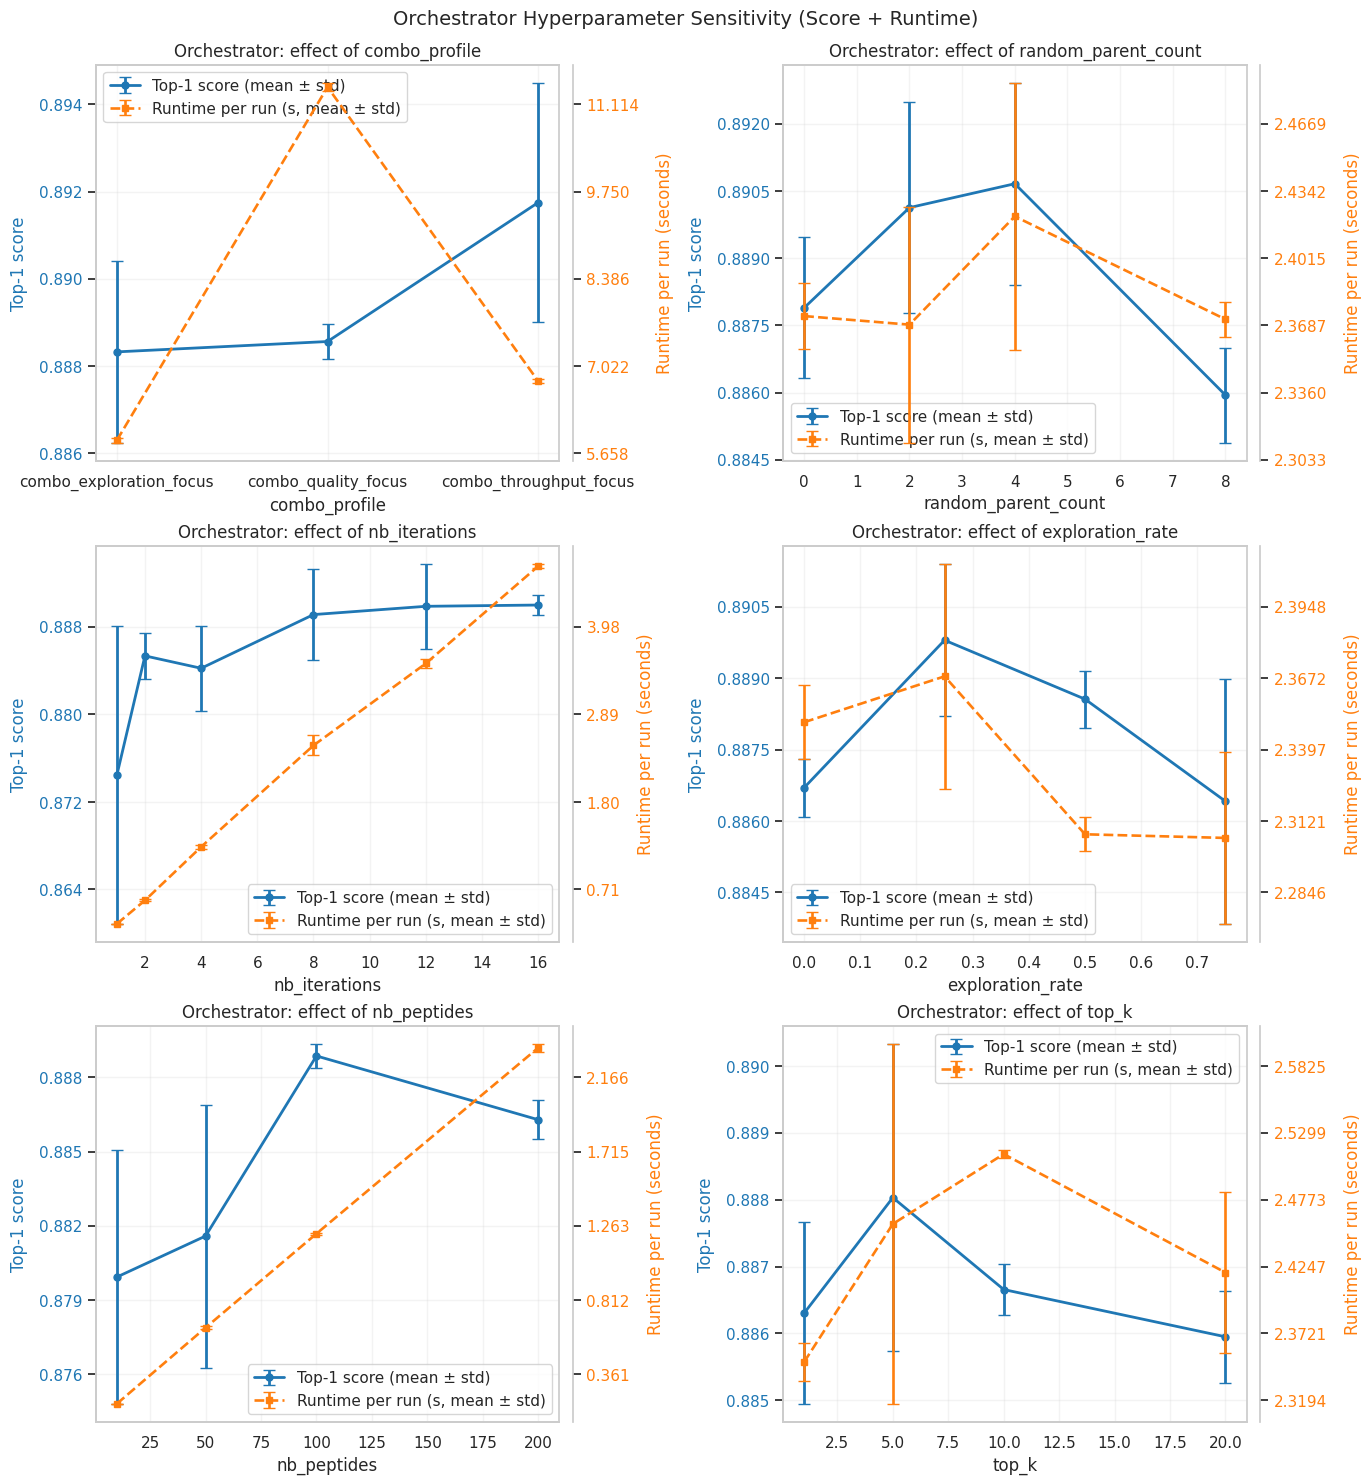

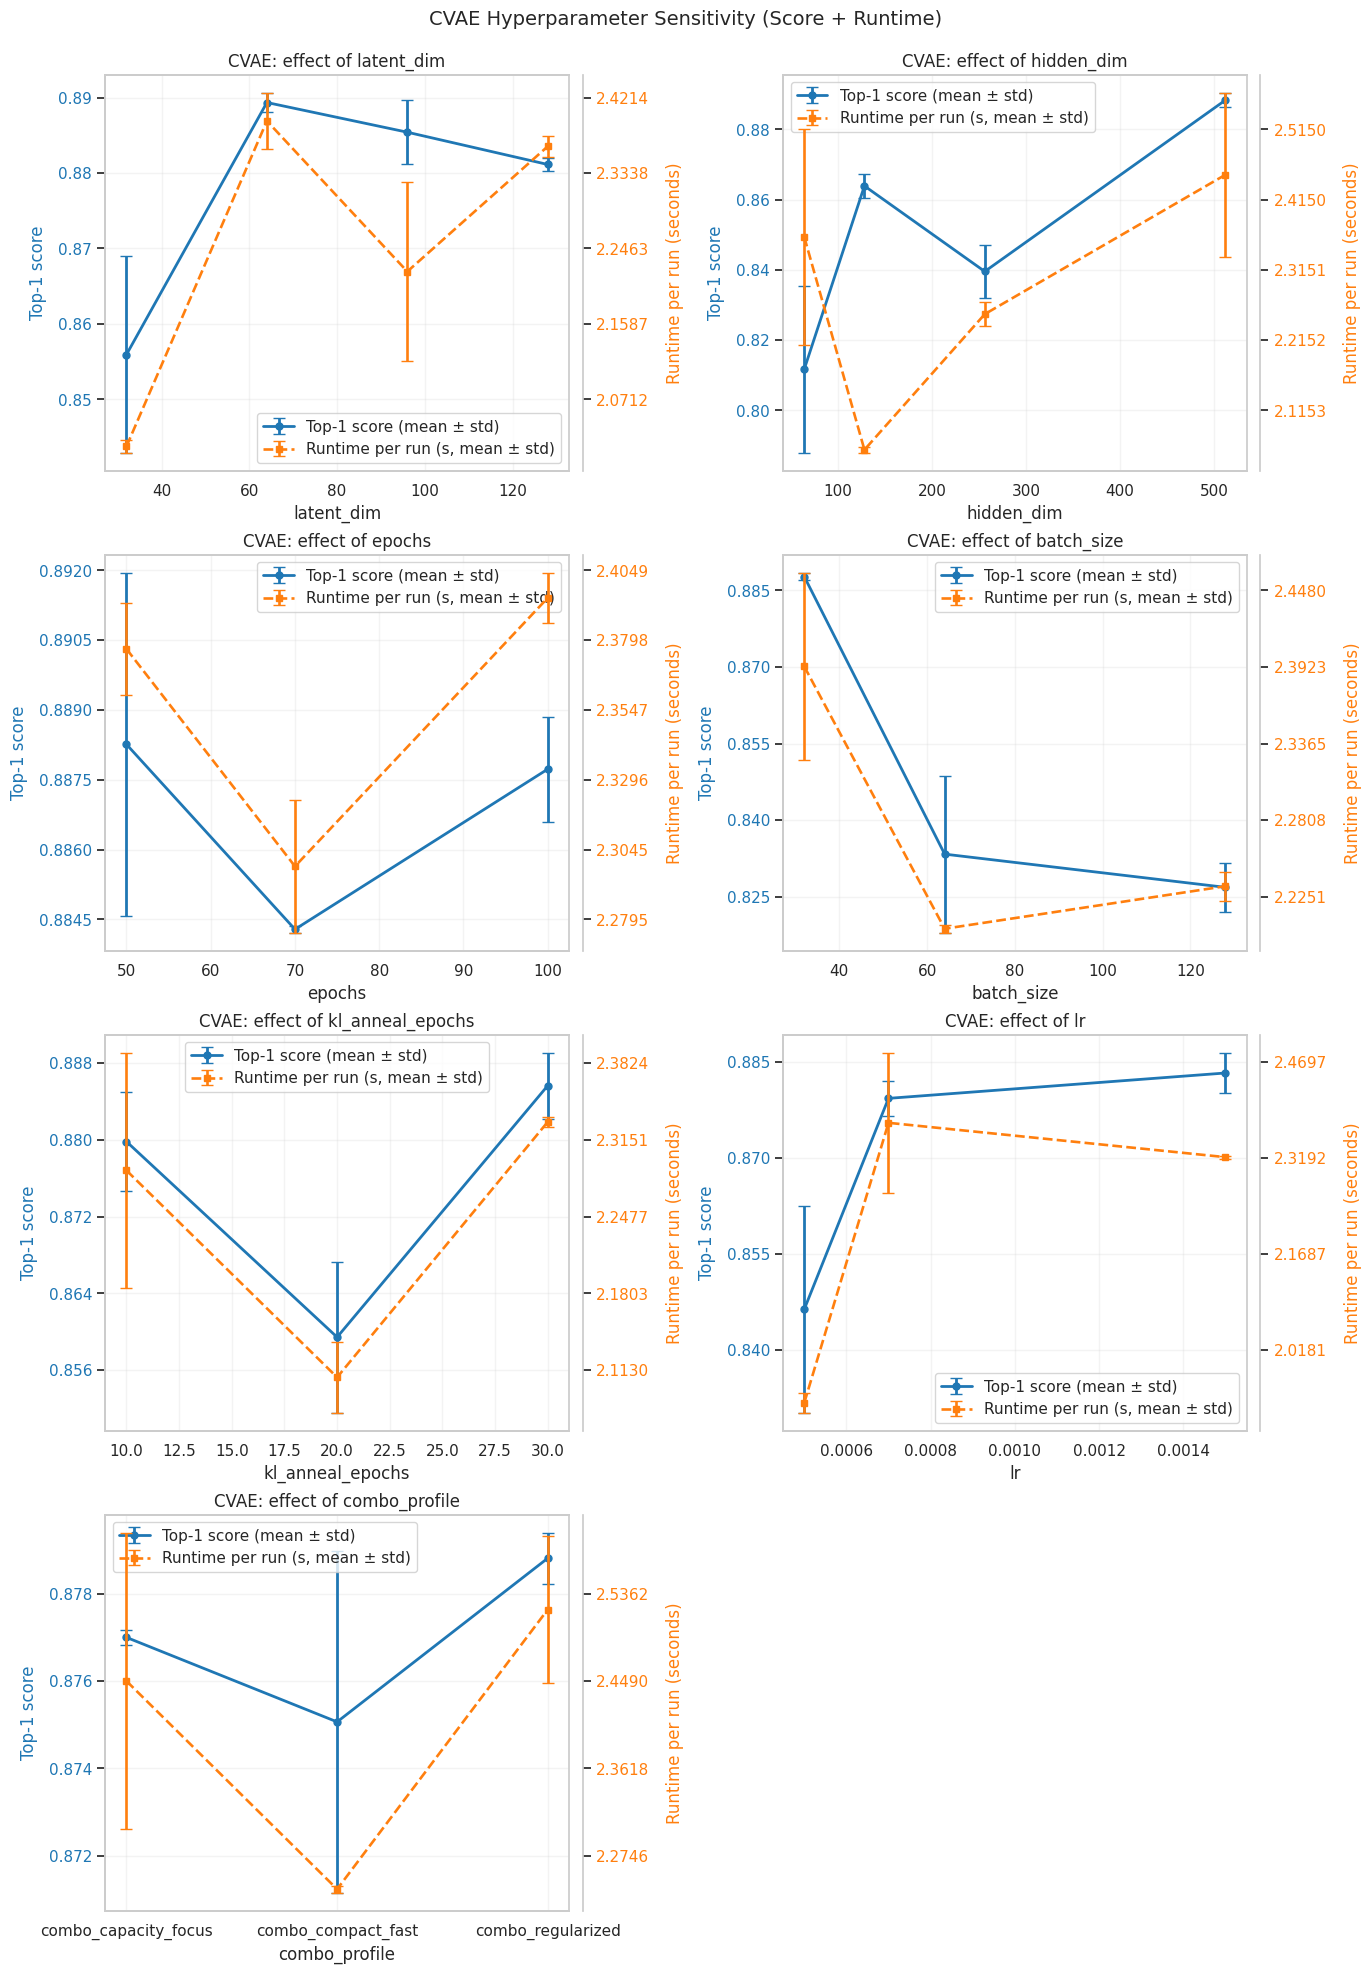

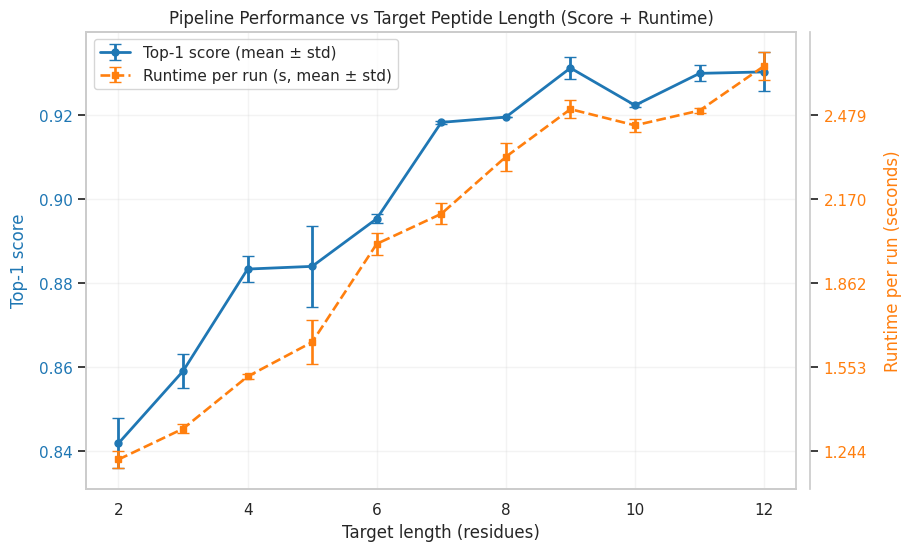

,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.888711,0.00089,0.884131,0.001091,1.0,0.0,1.0,0.0,0.658586,0.014285,4.542485,0.069135,2.57826,0.021069


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="whitegrid")

def align_dual_y_ticks(ax, ax2, n_ticks=6):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))

    y1_ticks = ax.get_yticks()
    y1_min, y1_max = ax.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    if len(y1_ticks) > 1 and y1_max > y1_min:
        y2_ticks = np.interp(y1_ticks, [y1_min, y1_max], [y2_min, y2_max])
        if len(y2_ticks) > 2:
            ax2.set_yticks(y2_ticks[1:-1])
        else:
            ax2.set_yticks(y2_ticks)

def style_dual_axis(ax, ax2):
    ax.grid(True, which='major', axis='both', alpha=0.22, zorder=0)
    ax.set_axisbelow(True)
    ax2.grid(False)

    ax.yaxis.labelpad = 8
    ax2.yaxis.labelpad = 12
    ax2.spines['right'].set_position(('outward', 10))

    align_dual_y_ticks(ax, ax2, n_ticks=6)

def plot_single_parameter_sweep(df, param_name, ax=None):
    if df.empty:
        return
    subset = df[df['param_name'] == param_name].sort_values('param_value')
    if subset.empty:
        return

    try:
        subset['param_value'] = pd.to_numeric(subset['param_value'])
        subset = subset.sort_values('param_value')
    except Exception:
        pass

    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 4.8))

    ax2 = ax.twinx()

    h1 = ax.errorbar(
        subset['param_value'],
        subset['top1_score_mean'],
        yerr=subset['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel(param_name)
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')

    h2 = ax2.errorbar(
        subset['param_value'],
        subset['elapsed_sec_mean'],
        yerr=subset['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')

if 'orchestrator_results_df' in globals() and not orchestrator_results_df.empty:
    params = [p for p in orchestrator_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(orchestrator_results_df, p, axes[i])
        axes[i].set_title(f'Orchestrator: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('Orchestrator Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()

if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    params = [p for p in cvae_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(cvae_results_df, p, axes[i])
        axes[i].set_title(f'CVAE: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('CVAE Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()

if 'length_sweep_summary_df' in globals() and not length_sweep_summary_df.empty:
    fig, ax = plt.subplots(figsize=(9.0, 5.4), constrained_layout=True)
    metrics = length_sweep_summary_df.sort_values('target_length').copy()

    ax2 = ax.twinx()

    h1 = ax.errorbar(
        metrics['target_length'],
        metrics['top1_score_mean'],
        yerr=metrics['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel('Target length (residues)')
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title('Pipeline Performance vs Target Peptide Length (Score + Runtime)')

    h2 = ax2.errorbar(
        metrics['target_length'],
        metrics['elapsed_sec_mean'],
        yerr=metrics['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')

    plt.show()

if 'pipeline_reference_summary_df' in globals() and not pipeline_reference_summary_df.empty:
    display(pipeline_reference_summary_df)

In [28]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()